# Random Forest Model — Proposal-Compliant Predictor Set

This notebook trains and evaluates the spring drying classification model using **only the predictor set defined in the finalized proposal** (`Revised Proposal 16th July.docx`, Section 7.1 and Objective 1):

> "Climate predictors will be derived from ERA5-Land reanalysis data. Land use/land cover, geological, and road-network layers, though available from prior data preparation, are **not used as predictors** in this phase of the study... Land use/land cover and geological factors... are excluded as modelled predictors in this study."

Per Objective 1, the modeled predictors are strictly:
- Climate variables: 15-year mean and Mann-Kendall trend (Sen's slope) of temperature, precipitation, dewpoint, and evaporation
- Spring-intrinsic attribute: perennial/seasonal classification

**Excluded** (unlike the earlier exploratory/refined notebooks in this folder, which retained these): elevation, aspect, slope, road-direction counts, land use/land cover, and geology.

Section 7.3 of the proposal also requires a multicollinearity check on the climate predictor set before training, since the earlier exploratory analysis found overlapping information among temperature/dewpoint/evaporation trend variables. This notebook applies that check (VIF) before finalizing the feature set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

RANDOM_STATE = 42
pd.set_option('display.width', 120)

In [2]:
data = pd.read_csv('../Full_Analysis_data.csv')
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])
print(data.shape)
data.head()

(3287, 38)


,Latitude,Longitude,Perennial / Seasonal,Dried since how many years?,Source Condition,Elev,Aspect,geometry,Formation,Rocktypes,...,Slope_cos,LU,Dewpoint_rate,Temperature_rate,Precipitation_rate,Evaporation_rate,Dewpoint_mean,Temperature_mean,Precipitation_mean,Evaporation_mean
0,27.556629,85.596365,perennial,NaN,active,1638.0,248.687530,POINT (361422.324611507 3048874.854799143),Formation II,"Banded gneiss, marble",...,0.000027,"[7, 7, 7, 7, 7, 4, 4, 4, 4, 4, 7, 7, 7, 7, 7, ...",0.038090,0.041817,24.755398,0.000015,12.998818,17.667891,2577.153037,-0.003904
1,27.565024,85.638463,perennial,2017.0,dried,1218.0,123.929794,POINT (365589.2869813394 3049758.535742284),Formation II,"Banded gneiss, marble",...,0.000098,"[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, ...",0.013289,0.026505,16.348608,-0.000002,12.944189,17.668510,2496.272664,-0.004054
2,27.544086,85.569624,perennial,NaN,active,1425.0,213.076830,POINT (358765.9169889486 3047515.4057141286),Formation II,"Banded gneiss, marble",...,0.000018,"[4, 4, 4, 4, 4, 7, 7, 7, 7, 7, 4, 4, 4, 4, 4, ...",0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
3,27.545604,85.570672,perennial,NaN,active,1483.0,261.869900,POINT (358871.3259907726 3047682.402644412),Formation II,"Banded gneiss, marble",...,0.000070,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627
4,27.545577,85.570475,perennial,NaN,active,1483.0,261.869900,POINT (358851.8899854751 3047679.6219697036),Formation II,"Banded gneiss, marble",...,0.000070,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 7, ...",0.038934,0.039005,19.937735,0.000023,11.937266,16.491294,2575.498471,-0.004627


## Feature selection (proposal-scoped) and target/attribute encoding

In [3]:
climate_cols = ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Evaporation_rate',
                'Dewpoint_mean', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean']

df = data[['Perennial / Seasonal', 'Source Condition'] + climate_cols].copy()

df['Perennial / Seasonal'] = df['Perennial / Seasonal'].map(lambda v: 1 if str(v).strip().lower() == 'perennial' else 0)
df['Source Condition'] = df['Source Condition'].map(lambda v: 1 if str(v).strip().lower() == 'dried' else 0)

df = df.dropna()
print('Rows after dropping NaN:', df.shape[0], 'of', data.shape[0])

le = LabelEncoder()
y = le.fit_transform(df['Source Condition'])
print('Target classes:', le.classes_)
df['Source Condition'].value_counts()

Rows after dropping NaN: 3285 of 3287


Target classes: [0 1]


Source Condition
0    2560
1     725
Name: count, dtype: int64

## Multicollinearity screening (VIF) on the climate predictor set

Per Section 7.3 of the proposal: "a multicollinearity check (e.g., variance inflation factor screening or correlation-based filtering) will be applied to the climate predictor set before model training, retaining the most informative and least redundant variables." VIF is computed manually here (regressing each candidate predictor on the rest via OLS and taking `1 / (1 - R^2)`) to avoid an extra library dependency.

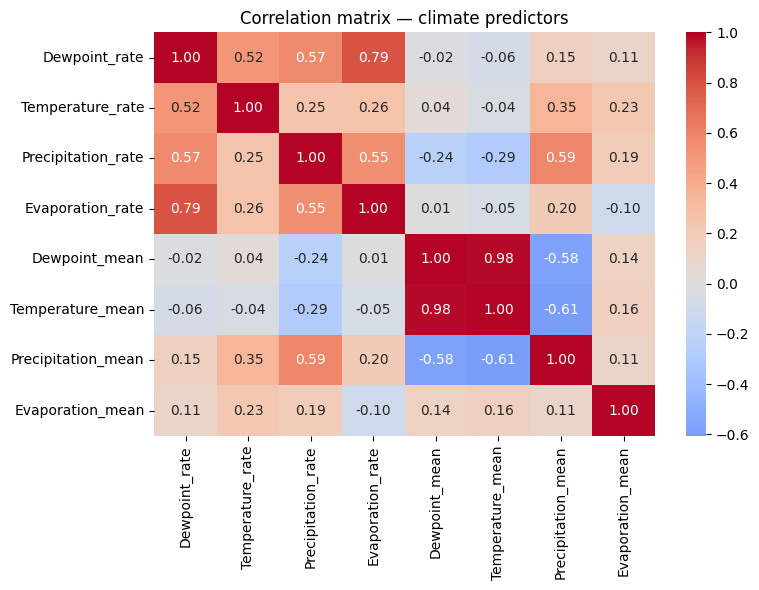

Dewpoint_mean         44.701129
Temperature_mean      44.200316
Dewpoint_rate          5.983465
Evaporation_rate       4.014632
Precipitation_mean     3.750015
Precipitation_rate     3.099712
Temperature_rate       2.821237
Evaporation_mean       1.383642
dtype: float64


In [4]:
def compute_vif(frame, cols):
    scaler = StandardScaler()
    scaled = pd.DataFrame(scaler.fit_transform(frame[cols]), columns=cols)
    vifs = {}
    for col in cols:
        X_others = scaled.drop(columns=[col]).values
        y_target = scaled[col].values
        r2 = LinearRegression().fit(X_others, y_target).score(X_others, y_target)
        vifs[col] = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

corr = df[climate_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — climate predictors')
plt.tight_layout()
plt.savefig('climate_predictor_correlation.png', dpi=300)
plt.show()

vif_series = compute_vif(df, climate_cols)
print(vif_series)

In [5]:
# Drop variables with VIF > 10 (standard threshold) iteratively, most-collinear first,
# unless doing so would remove both the mean and trend of a variable (keep at least one form of each climate driver).
VIF_THRESHOLD = 10.0
selected_cols = list(climate_cols)

while True:
    vifs = compute_vif(df, selected_cols)
    worst_col, worst_val = vifs.index[0], vifs.iloc[0]
    if worst_val <= VIF_THRESHOLD or len(selected_cols) <= 2:
        break
    selected_cols.remove(worst_col)
    print(f'Dropping {worst_col} (VIF={worst_val:.2f})')

print('\nFinal climate predictors after VIF screening:', selected_cols)
print('\nFinal VIF values:')
print(compute_vif(df, selected_cols))

Dropping Dewpoint_mean (VIF=44.70)

Final climate predictors after VIF screening: ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Evaporation_rate', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean']

Final VIF values:
Dewpoint_rate         5.496363
Evaporation_rate      3.742073
Precipitation_mean    3.567959
Precipitation_rate    2.895199
Temperature_rate      2.200036
Temperature_mean      2.025740
Evaporation_mean      1.334125
dtype: float64


## Final feature matrix, train/test split, and model pipeline

70/30 stratified split and `RandomForestClassifier(n_estimators=2000, class_weight='balanced')` are kept consistent with the earlier exploratory/refined notebooks in this folder so results remain comparable, but the feature set is now restricted to what the proposal specifies: the VIF-screened climate variables plus perennial/seasonal.

In [6]:
feature_cols = selected_cols + ['Perennial / Seasonal']
X = df[feature_cols].astype(float)
print('Final feature set:', feature_cols)
print('X shape:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train class balance:', np.bincount(y_train) / len(y_train))
print('Test class balance:', np.bincount(y_test) / len(y_test))

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

Final feature set: ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Evaporation_rate', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean', 'Perennial / Seasonal']
X shape: (3285, 8)


Train: (2299, 8) Test: (986, 8)
Train class balance: [0.77946933 0.22053067]
Test class balance: [0.77890467 0.22109533]


## Evaluation

In [7]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['active(0)', 'dried(1)']))

Accuracy:  0.9959
Precision: 0.9820
Recall:    1.0000
F1-score:  0.9909
ROC-AUC:   1.0000

              precision    recall  f1-score   support

   active(0)       1.00      0.99      1.00       768
    dried(1)       0.98      1.00      0.99       218

    accuracy                           1.00       986
   macro avg       0.99      1.00      0.99       986
weighted avg       1.00      1.00      1.00       986



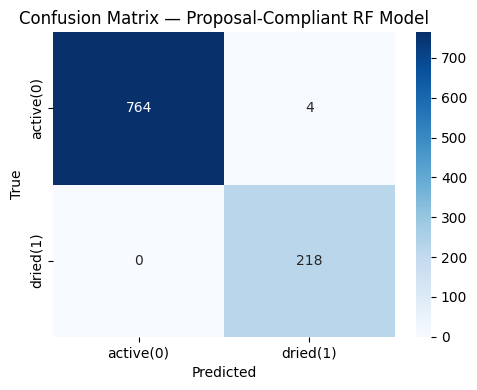

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['active(0)', 'dried(1)'], yticklabels=['active(0)', 'dried(1)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Proposal-Compliant RF Model')
plt.tight_layout()
plt.savefig('confusion_matrix_proposal_compliant.png', dpi=300)
plt.show()

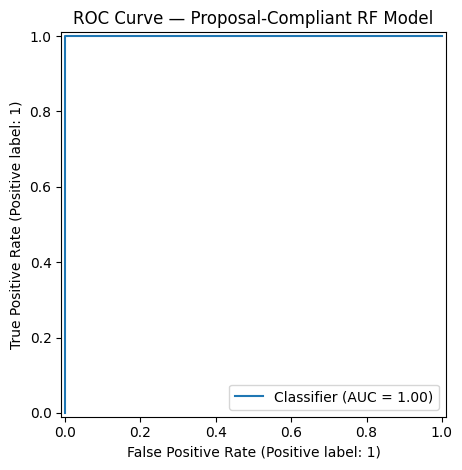

In [9]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — Proposal-Compliant RF Model')
plt.tight_layout()
plt.savefig('roc_curve_proposal_compliant.png', dpi=300)
plt.show()

In [10]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
print('5-fold CV F1 scores:', cv_scores)
print('Mean F1:', cv_scores.mean(), 'Std:', cv_scores.std())

5-fold CV F1 scores: [0.92948718 0.98601399 1.         1.         1.        ]
Mean F1: 0.9831002331002331 Std: 0.0273483302508871


Temperature_rate        0.372398
Dewpoint_rate           0.193656
Evaporation_rate        0.177807
Precipitation_mean      0.102560
Precipitation_rate      0.080480
Evaporation_mean        0.044539
Temperature_mean        0.017712
Perennial / Seasonal    0.010846
dtype: float64


C:\Users\kants\AppData\Local\Temp\ipykernel_25556\2383280717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


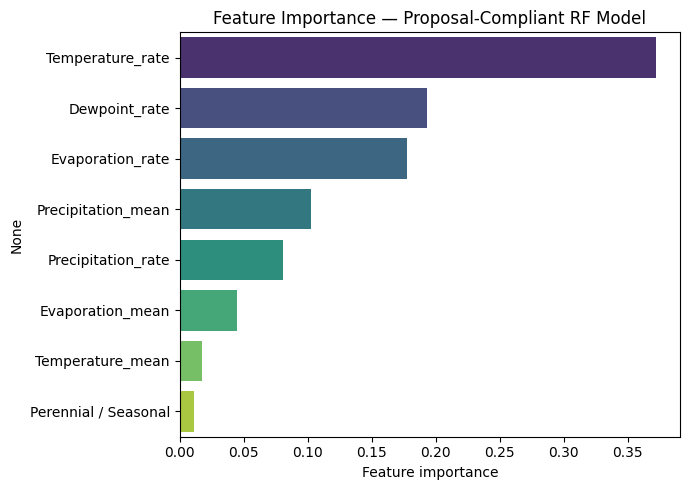

In [11]:
importances = pipeline.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(feat_imp)

plt.figure(figsize=(7, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.xlabel('Feature importance')
plt.title('Feature Importance — Proposal-Compliant RF Model')
plt.tight_layout()
plt.savefig('feature_importance_proposal_compliant.png', dpi=300)
plt.show()

## Summary

This model uses only the predictor set specified in the finalized proposal (climate means/trends + perennial-seasonal status), after VIF-based multicollinearity screening. Results above (accuracy, F1, ROC-AUC, confusion matrix, cross-validated F1, and feature importance) reflect this proposal-compliant scope and are directly comparable in structure to the exploratory/refined models in `random_forest_model_detailed.ipynb`, but are not expected to match their numbers since terrain and road-network predictors — which carried meaningful importance in those runs — are excluded here.